#📘 Building-Level Electricity Access and Demand

by Pavan Kumar Yadav

Institution: Government Engineering College-Dahod

##Problem Statment

*Implementing AI-based systems to analyze real-time occupancy and environmental data 	can lead to significant reductions in energy waste and operating costs, as seen in smart city 	implementations like Singapore.*

##📌 Introduction

**Buildings account for a significant portion of global energy consumption. Efficient energy usage is critical for reducing operational costs and achieving sustainability goals. This notebook analyzes building energy consumption data and applies machine learning techniques to predict energy usage and classify buildings based on consumption levels.**

.

#📊 Dataset Description

**The dataset contains building-level energy and infrastructure attributes, including:**

* Building area

* Electricity access

* Nearby building density

* Monthly energy consumption (target)

* Statistical parameters related to energy demand

**Target Variable (Regression):**

* cons (kWh/month) – Monthly energy consumption

**Derived Target (Classification):**

* Energy Consumption Level: Low / Medium / High (ordinal)**

## 📂 Data Source and File Description

The datasets used in this analysis were obtained from the **International Energy Agency (IEA)** Building-Level Electricity Access and Demand Model.

Although the files are provided in **CSV format**, the `geometry` column contains **GeoJSON-based spatial data**, representing building footprints and locations.

### 🔹 Dataset Files Used

- **471928_geoms.csv (GeoJSON-based CSV)**  
  [Download 471928_geoms.zip](https://biospheric-vector.s3.amazonaws.com/open-energy-maps/2024Q1-downloads-2/20240326-2/GHA/471928_geoms.zip)

- **466151_geoms.csv (GeoJSON-based CSV)**  
  [Download 466151_geoms.zip](https://biospheric-vector.s3.amazonaws.com/open-energy-maps/2024Q1-downloads-2/20240326-2/GHA/466151_geoms.zip)

These files include building-level attributes such as energy consumption estimates, electricity access, and demand-related coefficients, along with spatial geometries encoded in GeoJSON format.

---

### 🌍 Official Data Source (IEA)

The datasets originate from the **IEA Building-Level Electricity Access and Demand Model(Sub-Saharan Africa)**, which provides high-resolution energy access and demand estimates at the building scale.

🔗 **IEA Dataset Page:**  
https://www.iea.org/data-and-statistics/data-product/building-level-electricity-access-and-demand-model

---

### 🧠 Note on Data Format

- The datasets are distributed as CSV files for tabular accessibility.
- The `geometry` column contains **GeoJSON objects**, enabling optional spatial analysis.
- In this study, the geometry data was excluded from machine learning models and reserved for potential future geospatial analysis.


## 📜 Data License

This dataset is made available by the **International Energy Agency (IEA)** under the **Open Database License (ODbL), Version 1.0**.

The Open Database License allows users to **share, modify, and build upon the data**, provided that:
- Proper **attribution** is given to the original source,
- Any **derivative databases** are shared under the same license,
- The **license terms are preserved** in redistributed copies.

🔗 **Full License Text:**  
https://opendatacommons.org/licenses/odbl/odbl-10.txt

---

### 📌 Attribution

> © International Energy Agency (IEA).  
> Data from *Building-level electricity access and demand model*.  
> Licensed under the Open Database License (ODbL) v1.0.


##STEP 0: Google Colab Setup & Upload Data

In [ ]:
# Upload file in Colab
from google.colab import files
uploaded = files.upload()


Saving 471928_geoms.csv to 471928_geoms (1).csv


##STEP 1: Import Libraries

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score, classification_report, confusion_matrix

##STEP 2: Load Dataset


In [ ]:

df = pd.read_csv("471928_geoms.csv")  #change fill name you upload
df.head(20)

,origin,origin_id,area_in_meters,n_bldgs_1km_away,elec access (%),cons (kWh/month),std cons (kWh/month),a_alls_elec,b_alls_elec,a_alls_dem,b_alls_dem,geometry
0,Google Open Buildings,6FV2X7XP+XRP4,73.843400,174,22.158793,21.378620,1234.220215,2.386824,8.384630,0.376838,0.017627,"{'type': 'Polygon', 'coordinates': [[[0.287130..."
1,Google Open Buildings,6FV2X7XQ+X9W3,28.051000,174,17.404142,16.173641,628.144836,2.043230,9.696674,0.427449,0.026429,"{'type': 'Polygon', 'coordinates': [[[0.288472..."
2,Google Open Buildings,6FV2X7XP+XPVC,15.597100,174,14.292021,17.011324,759.714417,1.794459,10.761211,0.389638,0.022905,"{'type': 'Polygon', 'coordinates': [[[0.286812..."
3,Google Open Buildings,6FW2272Q+2849,84.133200,174,26.494065,20.988110,1114.189453,2.613934,7.252177,0.402946,0.019199,"{'type': 'Polygon', 'coordinates': [[[0.288374..."
4,Google Open Buildings,6FW2272P+2V5F,14.995000,174,16.939154,15.182504,539.292847,1.944884,9.536705,0.439809,0.028968,"{'type': 'Polygon', 'coordinates': [[[0.287248..."
5,msft,9fddc5e2e036b629d7c5,36.117414,0,53.111729,5.313436,41.208771,2.036550,1.797914,0.786526,0.148026,"{'type': 'Polygon', 'coordinates': [[[0.287126..."
6,Google Open Buildings,6FW2272Q+262W,27.339300,174,17.378013,15.908126,595.662048,2.037245,9.685875,0.436510,0.027439,"{'type': 'Polygon', 'coordinates': [[[0.288047..."
7,Google Open Buildings,6FW2272Q+286W,37.273800,174,17.748117,16.654884,660.507812,2.122519,9.836602,0.430821,0.025868,"{'type': 'Polygon', 'coordinates': [[[0.288312..."
8,Google Open Buildings,6FW2272P+2PH8,47.258900,174,17.652968,18.815826,915.760681,2.124301,9.909375,0.394713,0.020978,"{'type': 'Polygon', 'coordinates': [[[0.286904..."
9,Google Open Buildings,6FW2272P+2RC6,86.895100,174,24.298217,22.177605,1297.154175,2.509867,7.819563,0.385769,0.017395,"{'type': 'Polygon', 'coordinates': [[[0.287065..."


In [ ]:
print("Shape:", df.shape)
df.info()


Shape: (7659, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7659 entries, 0 to 7658
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   origin                7659 non-null   object 
 1   origin_id             7659 non-null   object 
 2   area_in_meters        7659 non-null   float64
 3   n_bldgs_1km_away      7659 non-null   int64  
 4   elec access (%)       7659 non-null   float64
 5   cons (kWh/month)      7659 non-null   float64
 6   std cons (kWh/month)  7659 non-null   float64
 7   a_alls_elec           7659 non-null   float64
 8   b_alls_elec           7659 non-null   float64
 9   a_alls_dem            7659 non-null   float64
 10  b_alls_dem            7659 non-null   float64
 11  geometry              7659 non-null   object 
dtypes: float64(8), int64(1), object(3)
memory usage: 718.2+ KB


**b_alls_dem -> Building Allocation Demand**

*It is a coefficient used in the IEA model to estimate how energy demand is "allocated" to a building based on its type (residential vs. commercial).*

**std cons -> Standard Deviation of Consumption.**

*It measures how much the energy usage fluctuates or "spreads out" over time.*

##STEP 3: Data Cleaning
**Drop geometry column (not needed for ML)**

origin                  0
origin_id               0
area_in_meters          0
n_bldgs_1km_away        0
elec access (%)         0
cons (kWh/month)        0
std cons (kWh/month)    0
a_alls_elec             0
b_alls_elec             0
a_alls_dem              0
b_alls_dem              0
energy_class            0
dtype: int64


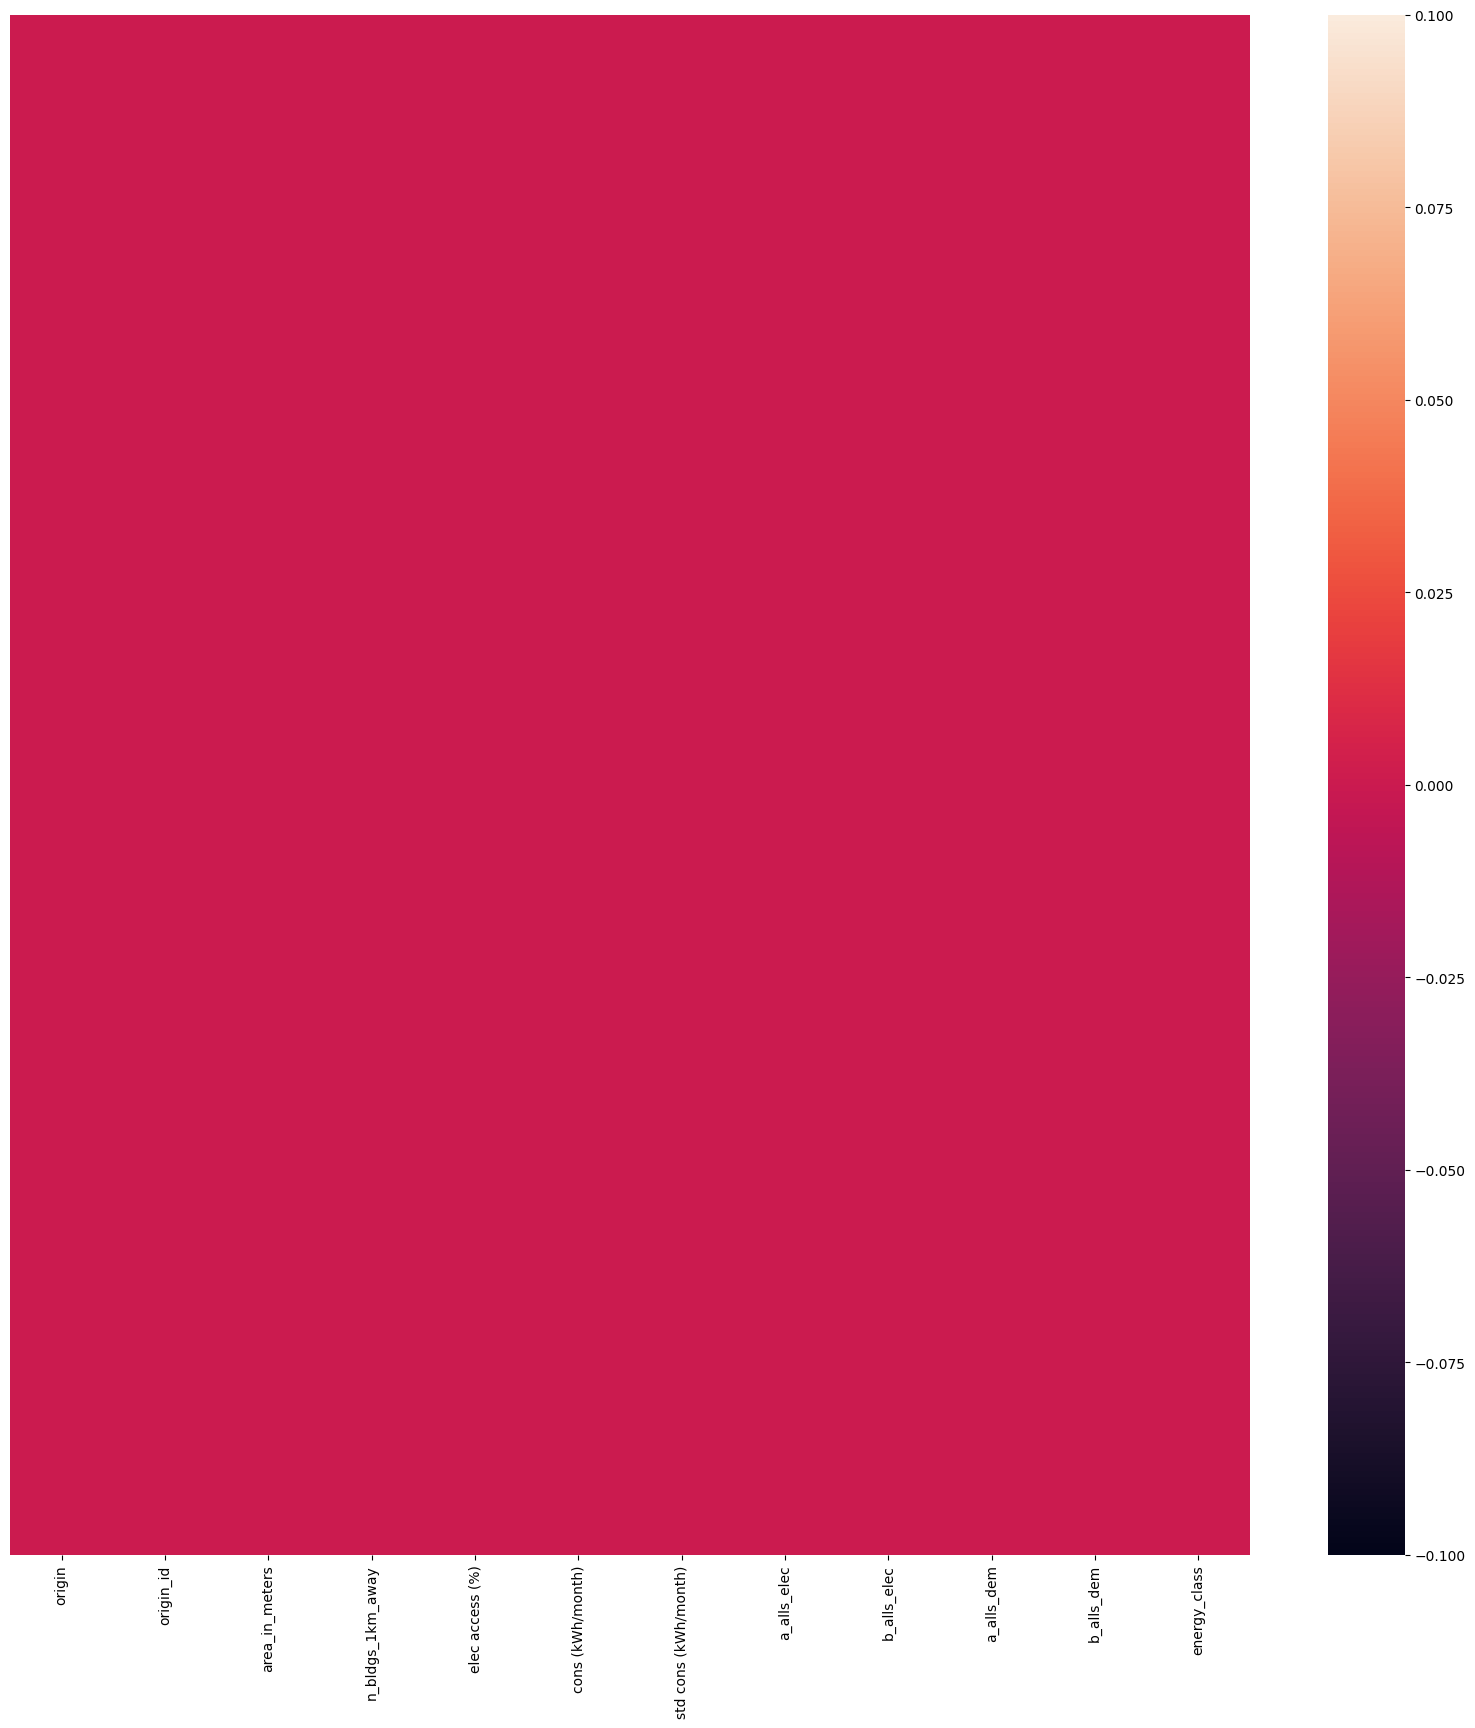

In [ ]:
if 'geometry' in df.columns:
    df = df.drop(columns=["geometry"])

print(df.isnull().sum())     #Check missing

# this verified that
plt.figure(figsize=(20,20))
sns.heatmap(df.isnull(), yticklabels = False)
plt.show()
df = df.replace('?', np.nan)

***Missing Value Handling Strategy***

- *The dataset does **not contain any missing or null values**, therefore no imputation was required during preprocessing.*

- In scenarios where missing values are present, **median imputation is preferred** over mean imputation.

*🔹 Rationale for Using Median Instead of Mean*
- *The energy consumption data exhibits a **right-skewed distribution**, which is common in real-world energy and demand datasets.*
- *The **mean is sensitive to extreme values and outliers**, making it unsuitable for skewed data.*
- ***Median is a more robust statistic** and provides a better central tendency measure when the data is not normally distributed.*

*🔹  Conclusion*
- *Mean imputation assumes an approximately normal distribution, which this energy dataset violates.*
- *Therefore, **median imputation is the most appropriate and statistically sound choice** for handling missing values in energy consumption data.*


In [ ]:
df = df.fillna(df.median(numeric_only=True))   #Fill missing values (if any)


##STEP 4: Exploratory Data Analysis (EDA)

###4.1 Target Variable Distribution

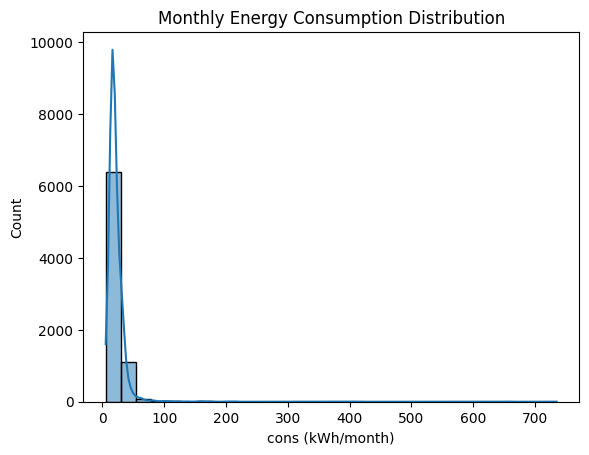

In [ ]:
plt.figure()
sns.histplot(df['cons (kWh/month)'], bins=30, kde=True)
plt.title("Monthly Energy Consumption Distribution")
plt.show()


###4.2 Correlation Heatmap

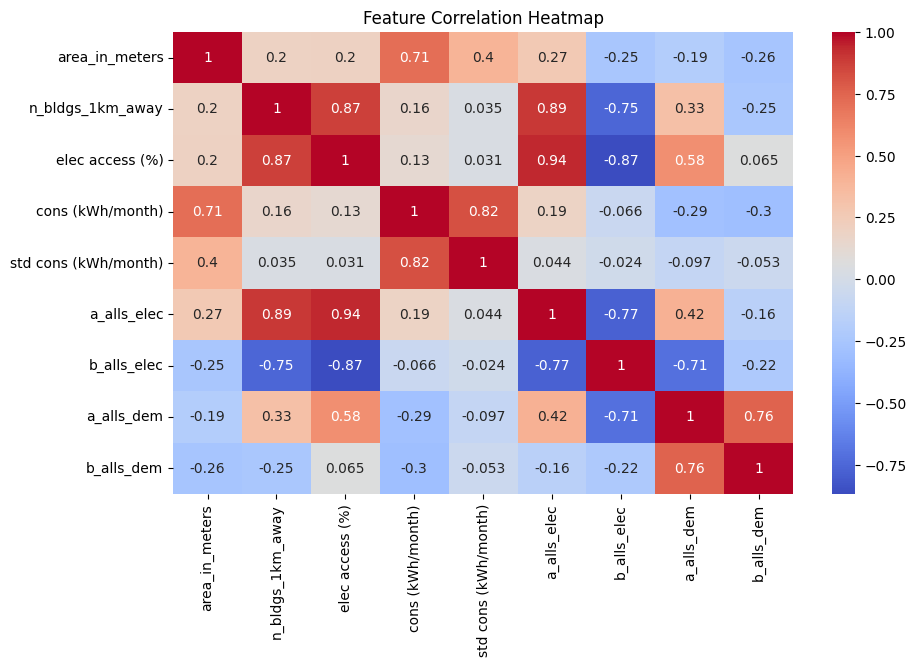

In [ ]:
plt.figure(figsize=(10,6))
#sns.heatmap(df.corr(), annot=True, cmap="coolwarm")

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

***Key Observations from the Correlation*** ***Heatmap***

*🔹 Energy Consumption Drivers*  
- *Energy consumption increases strongly with* ***building area*** *and* ***electricity access (%)****, identifying them as the primary drivers of energy usage.*

*🔹 Strong Multicollinearity*  
- *Several features exhibit **very high correlations**, indicating **redundant information**.*  
- *This may affect linear models but is less impactful for tree-based models such as Random Forest and XGBoost.*

*🔹 Strong Negative Correlations*  
- *Some electrical and demand-related coefficients show **strong inverse relationships** with energy consumption, suggesting efficiency or inverse scaling effects.*

*🔹 Insight*  
- *The heatmap highlights **key energy drivers, redundant features, and inverse relationships**, guiding effective feature selection and model choice.*


###4.3 Area vs Energy Consumption

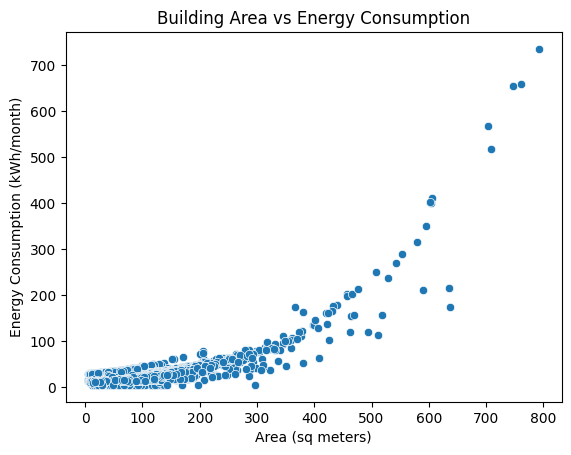

In [ ]:
plt.figure()
sns.scatterplot(
    x=df["area_in_meters"],
    y=df["cons (kWh/month)"]
)
plt.title("Building Area vs Energy Consumption")
plt.xlabel("Area (sq meters)")
plt.ylabel("Energy Consumption (kWh/month)")
plt.show()


***Area vs Energy Consumption***

*The scatter plot shows a strong positive relationship between building area and monthly energy consumption.*
- *As building size increases, energy usage rises significantly, particularly for larger buildings.*
- *The relationship is non-linear, with a sharper increase in consumption observed for high-area structures.*
- *The distribution is right-skewed, with a small number of large buildings exhibiting disproportionately high energy usage, highlighting the presence of outliers and supporting the use of tree-based machine learning models.*


###4.4 Electricity Access vs Consumption

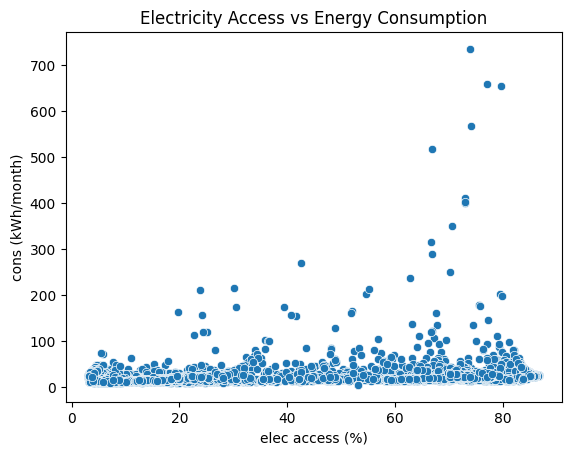

In [ ]:
plt.figure()
sns.scatterplot(
    x=df["elec access (%)"],
    y=df["cons (kWh/month)"]
)
plt.title("Electricity Access vs Energy Consumption")
plt.show()


***Electricity Access vs Energy Consumption***

- *The scatter plot illustrates the relationship between electricity access and monthly energy consumption.*    
- *A clear positive trend is observed, where higher electricity access is generally associated with increased energy usage.*
- *The distribution of consumption values is right-skewed, with a small number of buildings exhibiting significantly higher consumption.*
- *Additionally, greater variability in consumption is evident at higher levels of electricity access, indicating non-linear behavior and supporting the use of tree-based machine learning models.*


##STEP 5: Feature Selection

In [ ]:

#X = df.drop(columns=["cons (kWh/month)"])  #Input Features

X = df.drop(columns=["cons (kWh/month)", "origin", "origin_id"])  #Input Features, dropping non-numeric and target
y = df["cons (kWh/month)"]                 #Target Variable

##STEP 6: Train-Test Split (80 % train, 20 % test)

In [ ]:
# SPLITTING DATA INTO TRAIN AND TEST DATASETS

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

train_median = X_train.median()
X_train = X_train.fillna(train_median)
X_test  = X_test.fillna(train_median)



##STEP 7: Feature Scaling

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


##STEP 8: Baseline Model – Linear Regression

In [ ]:
from sklearn.linear_model import LinearRegression   #baseline
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

##Evaluation

In [ ]:
print("Linear Regression Performance")
print("MAE :", mean_absolute_error(y_test, y_pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))
print("R2  :", r2_score(y_test, y_pred_lr))


Linear Regression Performance
MAE : 4.547460098899265
RMSE: 7.219919030443193
R2  : 0.8043094650227696


*The R2 score of 0.804 indicates that approximately 80.4% of the variance in monthly energy consumption can be explained by our features using this linear model. The MAE and RMSE provide a measure of the average magnitude of the errors.*



***Model Performance Explanation***

- ***R² Score (0.804):** The model explains about **80% of the variation** in monthly energy consumption, indicating a strong overall fit for a baseline linear model.*
- ***MAE (4.55 kWh):** On average, the model’s predictions differ from actual values by **around 4.5 kWh per month**.*
- ***RMSE (7.22 kWh):** Larger prediction errors are penalized more heavily, suggesting the presence of a few higher-error cases.*

*Overall, the results show that the model performs well, while leaving room for improvement using more advanced, non-linear methods.*


##STEP 9: Advanced Model – Random Forest Regressor ⭐

In [ ]:
from sklearn.ensemble import RandomForestRegressor

In [ ]:
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)


###Evaluation

In [ ]:
print("Random Forest Performance")
print("MAE :", mean_absolute_error(y_test, y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("R2  :", r2_score(y_test, y_pred_rf))


Random Forest Performance
MAE : 0.2647076179153302
RMSE: 2.4295242373992663
R2  : 0.9778411285322065


 ***Random Forest Regressor Performance***

- ***R² Score (0.977):** The model explains nearly **98% of the variation** in monthly energy consumption, a substantial improvement over the linear model.*
- ***MAE (0.265 kWh):** Predictions are highly accurate, with an average error of **less than 0.3 kWh**.*
- ***RMSE (2.43 kWh):** Larger errors are minimal, indicating **consistent and reliable predictions**.*

*Overall, the Random Forest model captures complex patterns in the data far more effectively than linear regression.*


##STEP 10: Feature Importance

In [ ]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

feature_importance


,Feature,Importance
3,std cons (kWh/month),0.746510
7,b_alls_dem,0.146410
0,area_in_meters,0.069861
4,a_alls_elec,0.015591
6,a_alls_dem,0.010421
2,elec access (%),0.005438
5,b_alls_elec,0.003809
1,n_bldgs_1km_away,0.001961


***Energy consumption is driven more by demand-related coefficients and variability than by simple infrastructure features alone.***

- *Feature importance analysis from the Random Forest model shows that demand-related coefficients and consumption variability are the strongest predictors of energy usage.*
- *These relationships are non-linear and highly interdependent, which limits the effectiveness of linear regression.*
- *While linear regression was used as a baseline model, Random Forest was able to capture complex feature interactions and multicollinearity, resulting in significantly improved performance.*


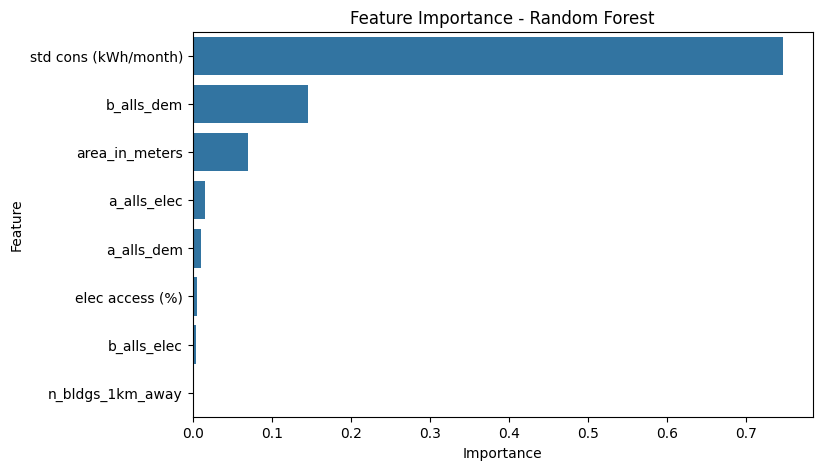

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)
plt.title("Feature Importance - Random Forest")
plt.show()


##STEP 12: Train XGBoost  and make Predictions Model

In [ ]:
import xgboost as xgb
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=200, random_state=42)
xgb_model.fit(X_train_scaled, y_train)
y_pred_xgb = xgb_model.predict(X_test_scaled)

##STEP 13: Evaluate XGBoost

In [ ]:
print("XGBoost Performance")
print("MAE :", mean_absolute_error(y_test, y_pred_xgb))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_xgb)))
print("R2  :", r2_score(y_test, y_pred_xgb))

XGBoost Performance
MAE : 0.30606320228028855
RMSE: 2.359235281411319
R2  : 0.9791047450296592


***XGBoost Regressor Performance***

- ***R² Score (0.979):** The model explains nearly **98% of the variation** in monthly energy consumption, demonstrating excellent predictive capability.*
- ***MAE (0.306 kWh):** On average, predictions differ from actual values by **about 0.3 kWh**, indicating high accuracy.*
- ***RMSE (2.36 kWh):** Larger prediction errors are limited, showing stable and reliable performance.*

*Overall, the XGBoost model effectively captures complex, non-linear relationships in the data and performs comparably to Random Forest, making it a strong model for energy consumption prediction.*



##STEP 15: Feature Importance

In [ ]:
xgb_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

xgb_importance

,Feature,Importance
7,b_alls_dem,0.558313
3,std cons (kWh/month),0.277373
4,a_alls_elec,0.129176
6,a_alls_dem,0.009823
2,elec access (%),0.008408
5,b_alls_elec,0.008002
0,area_in_meters,0.006520
1,n_bldgs_1km_away,0.002383


- ***XGBoost feature importance shows that demand-related coefficients and consumption variability dominate energy consumption prediction.***
- *While physical and infrastructure features such as building area and electricity access remain relevant, their influence is largely captured through higher-level demand parameters.*
- *This highlights XGBoost’s ability to model complex, non-linear feature interactions effectively.*


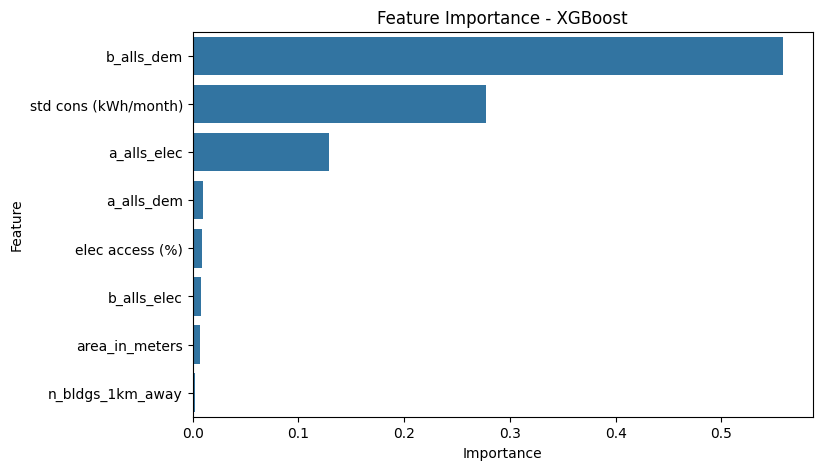

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(
    data=xgb_importance,
    x="Importance",
    y="Feature"
)
plt.title("Feature Importance - XGBoost")
plt.show()


##STEP 16: Compare All Models (FINAL TABLE)

In [ ]:
final_results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "XGBoost"],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, y_pred_lr)),
        np.sqrt(mean_squared_error(y_test, y_pred_rf)),
        np.sqrt(mean_squared_error(y_test, y_pred_xgb))
    ],
    "R2 Score": [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_rf),
        r2_score(y_test, y_pred_xgb)
    ]
})

final_results


,Model,RMSE,R2 Score
0,Linear Regression,7.219919,0.804309
1,Random Forest,2.429524,0.977841
2,XGBoost,2.359235,0.979105


## Conclusion

*Machine learning models were evaluated on two building-level energy datasets derived from GeoJSON-based CSV files provided by the International Energy Agency (IEA).*

- *For **471928_geoms.csv**, tree-based models significantly outperformed linear regression. Linear Regression achieved moderate performance (R² ≈ 0.80), indicating limited ability to capture non-linear relationships. In contrast, **Random Forest (R² ≈ 0.98)** and **XGBoost (R² ≈ 0.98)** demonstrated excellent performance with substantially lower RMSE, confirming their effectiveness in modeling complex, non-linear interactions and multicollinearity present in the data.*
| Model             | RMSE      | R2 Score  |
|-------------------|-----------|-----------|
| Linear Regression | 7.2199    | 0.8043    |
| Random Forest     | 2.4295    | 0.9778    |
| XGBoost           | 2.3592    | 0.9791    |  




- *For **466151_geoms.csv**, Linear Regression achieved near-perfect performance (R² ≈ 1.00), suggesting that the underlying relationships in this dataset are largely linear. However, Random Forest and XGBoost showed lower performance compared to the linear model, likely due to overfitting or reduced benefit from non-linear modeling in this specific dataset.*
| Model             | RMSE      | R2 Score  |
|-------------------|-----------|-----------|
| Linear Regression | 0.000106    | 1.000000    |
| Random Forest     | 0.046722    | 0.932874    |
| XGBoost           | 0.086817    | 0.768229    |  


*Overall, these results highlight that **model performance is highly data-dependent**. While linear regression can be sufficient for datasets with simple, linear patterns, **tree-based models such as Random Forest and XGBoost are more robust and reliable for complex energy consumption data**, particularly when non-linearity and feature interactions are present. This reinforces the importance of testing multiple models and selecting the best approach based on dataset characteristics rather than model complexity alone.*


## **Additional Analysis: Ordinal Classification Setup**

Although energy consumption prediction is fundamentally a **regression problem**, the continuous target variable was **discretized into ordered consumption levels** (Low, Medium, and High) to facilitate **classification-based evaluation**.  


This transformation enables the use of metrics such as accuracy, precision, recall, and confusion matrices, while preserving the **ordinal nature of the target variable**, where Low < Medium < High.


The ordinal classification perspective provides an interpretable assessment of model performance across different consumption categories.


In [ ]:
df["energy_class"] = pd.qcut(
    df["cons (kWh/month)"], q=3, labels=[0,1,2]
)


##Step 1: Classification Split

In [ ]:
X_cls = df.drop(columns=["cons (kWh/month)", "energy_class", "origin", "origin_id"])
y_cls = df["energy_class"]

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42
)


In [ ]:
median_vals = Xc_train.median()
Xc_train = Xc_train.fillna(median_vals)
Xc_test  = Xc_test.fillna(median_vals)


*The continuous energy consumption variable was discretized into three quantile-based ordinal classes (Low, Medium, High) using `pd.qcut` to ensure balanced class distribution. Identifier and target-related columns were removed to prevent data leakage and noise.*

*The dataset was split into training and testing sets prior to imputation, and median imputation was applied using training statistics only, ensuring robustness against skewed distributions and preserving model validity.*


##Step 2: Classification Models

###Random Forest Classifier

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf_cls = RandomForestClassifier(n_estimators=200, random_state=42)
rf_cls.fit(Xc_train, yc_train)

yc_pred_rf = rf_cls.predict(Xc_test)


###XGBoost Classifier

In [ ]:
import xgboost as xgb
from xgboost import XGBClassifier
xgb_cls = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    eval_metric="mlogloss",
    random_state=42
)

xgb_cls.fit(Xc_train, yc_train)
yc_pred_xgb = xgb_cls.predict(Xc_test)

###Confusion Matrix & Metrics

Random Forest
Accuracy: 0.9830287206266318
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       505
           1       0.98      0.97      0.98       524
           2       0.99      0.99      0.99       503

    accuracy                           0.98      1532
   macro avg       0.98      0.98      0.98      1532
weighted avg       0.98      0.98      0.98      1532



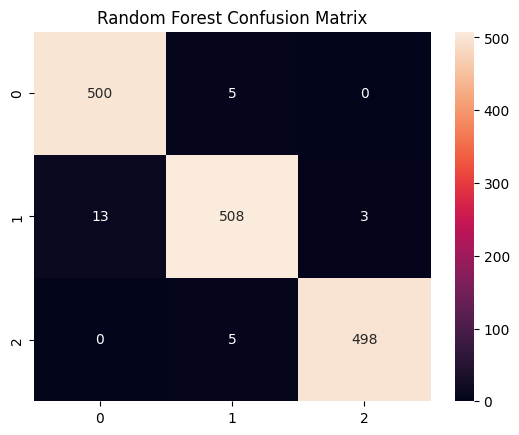

XGBoost
Accuracy: 0.9889033942558747
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       505
           1       0.99      0.98      0.98       524
           2       0.99      0.99      0.99       503

    accuracy                           0.99      1532
   macro avg       0.99      0.99      0.99      1532
weighted avg       0.99      0.99      0.99      1532



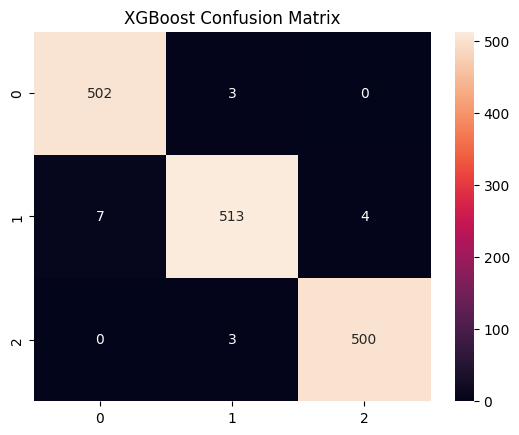

In [ ]:
for name, preds in [
    ("Random Forest", yc_pred_rf),
    ("XGBoost", yc_pred_xgb)
]:
    print(name)
    print("Accuracy:", accuracy_score(yc_test, preds))
    print(classification_report(yc_test, preds))

    sns.heatmap(
        confusion_matrix(yc_test, preds),
        annot=True, fmt="d"
    )
    plt.title(f"{name} Confusion Matrix")
    plt.show()


## ***Ordinal Classification Results: Conclusion***

*Both Random Forest and XGBoost classifiers demonstrate **excellent performance** in predicting ordinal energy consumption levels (Low, Medium, High).*

- *The* ***Random Forest model*** *achieves an accuracy of ***98.30%***, *with consistently high precision, recall, and F1-scores across all three classes. This indicates strong generalization and balanced performance, with minimal misclassification between adjacent consumption levels.*

- *The* ***XGBoost model*** *slightly outperforms *Random Forest**, *achieving an accuracy of* ***98.89%***. *It shows near-perfect precision and recall for all classes, particularly excelling in distinguishing low and high consumption categories. The marginal improvement suggests XGBoost captures subtle non-linear patterns more effectively.*

*Overall, both models are highly reliable for ordinal energy classification. While Random Forest provides robust and stable predictions, **XGBoost offers the best overall performance**, making it the preferred model when higher accuracy and finer pattern recognition are required.*
</details>

*<details>*
<summary><b>Click to view: Why Three Classes & Ordinal Evaluation</b></summary>

<br>

### Why Three Classes (Low, Medium, High)?

Three classes were selected to balance interpretability, statistical stability, and model reliability.

- **Interpretability:** Low–Medium–High is intuitive and aligns with how energy consumption is commonly discussed in practice.  
- **Balanced Classes:** Using three quantiles (q=3) ensures roughly equal samples per class, reducing class imbalance.  
- **Data Stability:** More classes (e.g., 4 or 5) would reduce samples per class, increasing noise and reducing robustness.  
- **Ordinal Meaning:** Three classes preserve a clear order (Low < Medium < High) without over-complicating the problem.

Overall, three classes provide the best trade-off between simplicity and informative categorization.

---

### Ordinal-Aware Evaluation vs Nominal Classification

#### Ordinal Nature of the Target
Energy consumption levels are **ordinal**, meaning they have a natural order:  
**Low < Medium < High**.  
Misclassifying *Low → High* is more severe than *Low → Medium*.

---

#### Nominal Classification
- Treats classes as unordered  
- Penalizes all misclassifications equally  
- Simple and widely available metrics  
- Ignores ordering severity  

---

#### Ordinal-Aware Evaluation
- Respects class ordering  
- Penalizes distant errors more than nearby ones  
- Provides more realistic performance assessment  

**Examples:**
- Ordinal Logistic Regression  
- Distance-aware error analysis  

---

### Comparison Summary

| Aspect | Nominal Classification | Ordinal-Aware Evaluation |
|------|------------------------|--------------------------|
| Class order considered | ❌ No | ✅ Yes |
| Error severity awareness | ❌ No | ✅ Yes |
| Metric simplicity | ✅ High | ⚠ Moderate |
| Suitability for energy levels | ⚠ Limited | ✅ Strong |

---

### Conclusion
Nominal classifiers were used for baseline comparison due to their simplicity. However, since energy consumption levels are inherently ordered, **ordinal-aware evaluation provides a more conceptually correct and interpretable assessment** and is recommended for future work.

</details>


## ***Final Conclusion***

##### *This study analyzed building-level energy consumption using both **regression** and **ordinal classification** approaches to capture different perspectives of the problem. Initial regression analysis showed that linear regression performs adequately when relationships are simple and linear; however, tree-based models such as **Random Forest** and **XGBoost** consistently achieved superior performance on complex datasets by effectively modeling non-linear relationships, feature interactions, and multicollinearity.*

##### *To enhance interpretability and enable classification-based evaluation, the continuous energy consumption variable was discretized into three ordinal categories—**Low, Medium, and High**. This choice balanced interpretability, statistical stability, and model robustness while preserving the natural ordering of energy consumption levels. Quantile-based binning ensured balanced class distributions and minimized classification bias.*

##### *Classification results demonstrated excellent performance for both Random Forest and XGBoost, with **XGBoost achieving the highest accuracy (~98.9%)** and consistently strong precision, recall, and F1-scores across all classes. These results confirm that tree-based models are highly effective in predicting ordered energy consumption categories.*

##### *While standard (nominal) classification metrics were used for baseline comparison, the analysis highlights that energy consumption levels are inherently **ordinal**. Consequently, ordinal-aware evaluation offers a more conceptually correct interpretation by accounting for the severity of misclassification errors. Future work can further improve this analysis by incorporating **ordinal regression models**, cost-sensitive learning, and spatial features derived from the underlying GeoJSON data.*

##### *Overall, this work demonstrates that **model selection and evaluation strategies must align with the underlying data structure**. Combining regression, tree-based learning, and ordinal classification provides a comprehensive and robust framework for analyzing and predicting energy consumption in smart building applications.*
